In [2]:
%pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [4]:
customers = pd.read_csv("Lumina Co CRM/customers.csv")
transactions = pd.read_csv("Lumina Co CRM/transactions.csv")
customers.head()

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days,declared_preference,age_bracket,life_stage,urban_density
0,56396,France,2026-05-18 00:00:00,2026-06-11 00:00:00,1,757.68,757.6800,19,24,NaN,NaN,NaN,Zone urbaine dense
1,14297,France,2025-09-28 19:41:00,2026-06-12 20:16:00,4,2325.35,581.3375,17,274,NaN,NaN,NaN,NaN
2,34160,France,2024-03-25 00:00:00,2025-06-03 00:00:00,1,519.12,519.1200,392,435,Peau sèche,45-54 ans,NaN,NaN
3,61352,France,2023-06-21 00:00:00,2025-03-02 00:00:00,4,6394.33,1598.5800,485,620,Peau sèche,35-44 ans,Jeune actif en solo,NaN
4,20612,France,2025-09-19 00:00:00,2026-06-17 00:00:00,9,5918.34,657.5900,13,271,NaN,NaN,NaN,NaN


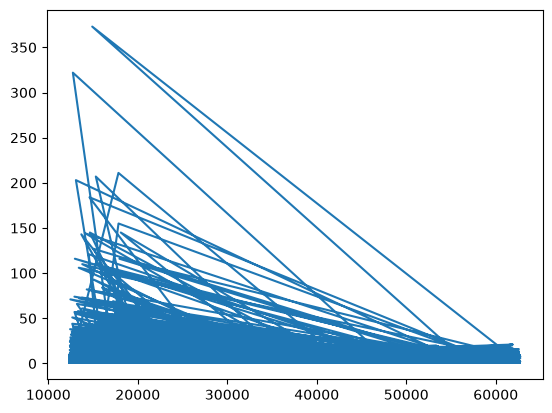

In [6]:
plt.plot(customers["customer_id"], customers["n_orders"])

ETAPE 1

In [ ]:
print(f"{customers.shape[0]} clients, {customers.shape[1]} colonnes")
print(f"{transactions.shape[0]} transactions, {transactions.shape[1]} colonnes")
print(f"Période : {transactions['invoice_date'].min()} → {transactions['invoice_date'].max()}")

50295 clients, 13 colonnes
1613433 transactions, 9 colonnes
Période : 2022-01-07 00:00:00 → 2026-06-30 00:00:00


Volumétrie et période couverte — sert de référence pour juger plus tard si un nettoyage a un impact significatif sur le volume

In [ ]:
print("Transactions :")
print((transactions.isna().mean() * 100).round(1).sort_values(ascending=False))
print("\nCustomers :")
print((customers.isna().mean() * 100).round(1).sort_values(ascending=False))

Transactions :
customer_id     22.8
product_name     0.1
invoice_id       0.0
product_code     0.0
category         0.0
quantity         0.0
unit_price       0.0
invoice_date     0.0
country          0.0
dtype: float64

Customers :
urban_density          80.2
life_stage             77.5
declared_preference    61.9
age_bracket            57.3
customer_id             0.0
country                 0.0
first_purchase          0.0
last_purchase           0.0
n_orders                0.0
total_spent             0.0
avg_basket              0.0
recency_days            0.0
tenure_days             0.0
dtype: float64


Taux de valeurs manquantes par colonne — un taux élevé sur une colonne clé (ex: customer_id) signale un point à investiguer avant de nettoyer quoi que ce soit

In [ ]:
print(transactions.dtypes)
print(customers.dtypes)

invoice_id          str
customer_id     float64
product_code        str
product_name        str
category            str
quantity          int64
unit_price      float64
invoice_date        str
country             str
dtype: object
customer_id              int64
country                    str
first_purchase             str
last_purchase              str
n_orders                 int64
total_spent            float64
avg_basket             float64
recency_days             int64
tenure_days              int64
declared_preference        str
age_bracket                str
life_stage                 str
urban_density              str
dtype: object


Diagnostic des types (ex: invoice_date probablement en object au lieu de datetime) — pas de correction ici, juste repérage, la conversion viendra quand elle sera utile

In [ ]:
print("Doublons exacts :", transactions.duplicated().sum())
print("Doublons invoice+produit :", transactions.duplicated(subset=["invoice_id", "product_code"]).sum())
print("Doublons customers :", customers.duplicated(subset=["customer_id"]).sum())

Doublons exacts : 445
Doublons invoice+produit : 47890
Doublons customers : 0


Détection de doublons à deux niveaux (exact vs logique) — un doublon non détecté fausse directement les agrégations de CA et de fréquence

ETAPE 2

In [ ]:
missing_cust = transactions[transactions["customer_id"].isna()]
print(f"{len(missing_cust)} lignes ({len(missing_cust)/len(transactions)*100:.1f}%)")
missing_cust[["product_code", "unit_price", "quantity"]].describe(include="all")

367328 lignes (22.8%)


,product_code,unit_price,quantity
count,367328,367328.000000,367328.000000
unique,5263,NaN,NaN
top,85123A,NaN,NaN
freq,1602,NaN,NaN
mean,NaN,19.478430,1.569850
std,NaN,11.900193,0.983188
min,NaN,-8.360000,-5.000000
25%,NaN,12.160000,1.000000
50%,NaN,17.060000,1.000000
75%,NaN,23.850000,2.000000


Isolement des customer_id manquants et comparaison de leur profil (prix, produits) au reste — si le profil est similaire, probablement des achats invités/caisse plutôt qu'une erreur d'export

In [ ]:
neg_qty = transactions[transactions["quantity"] < 0]
neg_qty["product_code"].value_counts().head(10)

product_code
M         540
22423     425
22138     248
85123A    245
21232     232
POST      230
21843     184
D         173
85099B    149
79323W    136
Name: count, dtype: int64

Quantités négatives — un pattern récurrent sur certains codes produits suggère des retours/avoirs légitimes (à garder pour le CA net, à exclure d'un calcul de fréquence d'achat)

In [ ]:
zero_price = transactions[transactions["unit_price"] == 0]
zero_price["product_code"].value_counts().head(10)

product_code
M         1422
S          104
22423       33
85123A      29
79321       25
23084       24
22469       23
85099B      23
84879       20
22139       20
Name: count, dtype: int64

Prix à zéro — récurrent sur un code = cas métier (promo, échantillon) ; aléatoire et rare = probable erreur d'export

In [ ]:
transactions["product_code"].value_counts().tail(30)

product_code
84897A    1
79003B    1
35925     1
84867a    1
37353     1
85086B    1
47285B    1
72755A    1
20720     1
35839     1
49031B    1
21176     1
21295     1
90142B    1
47595B    1
21104     1
47593b    1
72754C    1
16243A    1
21315     1
35004p    1
84642     1
21020     1
79053B    1
79070b    1
16155H    1
90080     1
35908C    1
79342b    1
21346     1
Name: count, dtype: int64

.tail() plutôt que .head() car les codes non-produits (frais de port, ajustements) apparaissent peu souvent, donc en bas d'un tri par fréquence décroissante

In [ ]:
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
transactions["line_total"].describe()

count    1.613433e+06
mean     3.136926e+01
std      2.958729e+01
min     -2.838500e+02
25%      1.441000e+01
50%      2.334000e+01
75%      4.110000e+01
max      2.886500e+02
Name: line_total, dtype: float64

Calcul du montant par ligne, utilisé dans toute l'étape 3 — le describe() juste après repère une incohérence immédiate (valeur extrême suspecte)

In [ ]:
bad_dates = customers[customers["first_purchase"] > customers["last_purchase"]]
print(len(bad_dates))

0


Cohérence des dates — une première date d'achat postérieure à la dernière est logiquement impossible, signale un souci d'agrégation côté CRM

In [ ]:
customers[["total_spent", "n_orders", "avg_basket"]].describe()

,total_spent,n_orders,avg_basket
count,50295.000000,50295.000000,50295.000000
mean,3373.702775,4.586042,724.183056
std,6004.065658,5.877529,656.605537
min,5.370000,1.000000,5.370000
25%,636.730000,1.000000,313.306667
50%,1597.360000,3.000000,560.960000
75%,3950.630000,6.000000,921.620000
max,416440.590000,373.000000,11891.230000


Repérage d'outliers via les quartiles — un max très éloigné du 75e percentile suggère un client B2B plutôt qu'une erreur, à vérifier

In [ ]:
(customers["n_orders"] == 1).mean()

np.float64(0.28750372800477186)

Proportion de clients one-shot vs récurrents — au-delà du nettoyage, ce chiffre est déjà un insight marketing sur la fidélité de la base

ETAPE 3

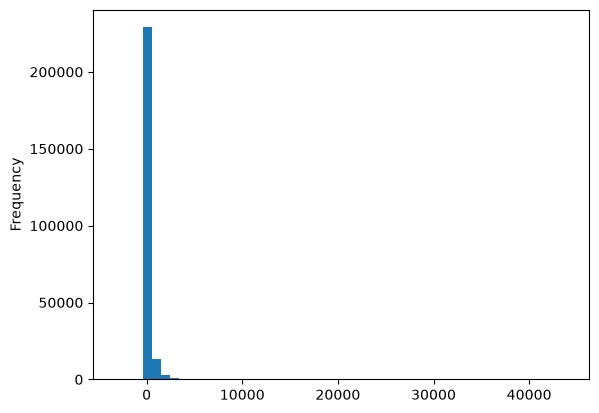

In [ ]:
invoice_totals = transactions.groupby("invoice_id")["line_total"].sum()
invoice_totals.plot(kind="hist", bins=50)
plt.show()

Distribution des paniers agrégée par facture (pas par ligne) — les outliers isolés à droite sont de potentiels clients B2B à traiter séparément en segmentation

In [ ]:
sorted_spend = customers.sort_values("total_spent", ascending=False)
sorted_spend["cum_pct"] = sorted_spend["total_spent"].cumsum() / sorted_spend["total_spent"].sum()
(sorted_spend["cum_pct"] <= 0.8).sum() / len(sorted_spend)

np.float64(0.3432945620837061)

Loi de Pareto — proportion de clients qui génèrent 80% du CA cumulé, chiffre clé pour prioriser une stratégie de fidélisation

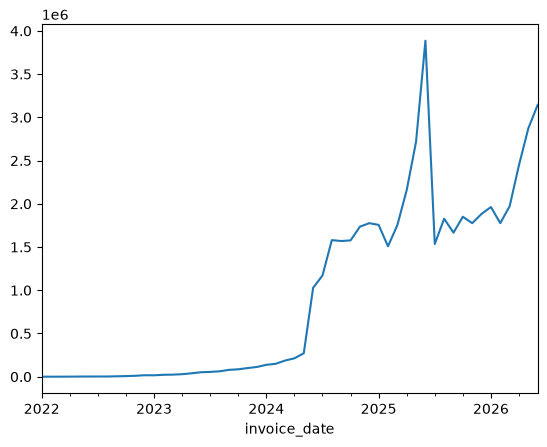

In [ ]:
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
transactions.groupby(transactions["invoice_date"].dt.to_period("M"))["line_total"].sum().plot()
plt.show()

Conversion en datetime (faite ici, au moment où elle sert réellement) puis CA mensuel — les pics visibles orientent le calendrier de campagnes

In [ ]:
transactions["country"].value_counts(normalize=True).head(10)

country
France            0.918834
Germany           0.017779
United Kingdom    0.014363
EIRE              0.011280
Netherlands       0.003982
Spain             0.003828
Belgium           0.003640
Switzerland       0.003147
Portugal          0.002862
Australia         0.001926
Name: proportion, dtype: float64

Répartition géographique en proportions — sert à repérer une éventuelle surreprésentation d'un pays, biais à documenter pour la segmentation de demain

In [ ]:
customers[["total_spent", "n_orders", "avg_basket"]].corr(method="spearman")

,total_spent,n_orders,avg_basket
total_spent,1.000000,0.76065,0.685572
n_orders,0.760650,1.00000,0.093360
avg_basket,0.685572,0.09336,1.000000


Corrélations en Spearman plutôt que Pearson par défaut — capte les relations monotones non linéaires, plus réalistes en comportement d'achat

In [ ]:
(transactions.groupby("category")["line_total"].sum() / transactions["line_total"].sum()).sort_values(ascending=False)

category
Visage        0.319317
Corps         0.207828
Coffret       0.206327
Cheveux       0.113780
Accessoire    0.081383
Bain          0.071036
Frais         0.000330
Name: line_total, dtype: float64

Répartition du CA par catégorie en pourcentage — sert de point de comparaison pour l'affinité produit des segments RFM au Jour 2

In [ ]:
for col in ["declared_preference", "age_bracket", "life_stage", "urban_density"]:
    print(col, customers[col].notna().mean())

declared_preference 0.3814892136395268
age_bracket 0.42696093050999107
life_stage 0.22485336514564072
urban_density 0.19809126155681478


Taux de remplissage des données zero-party — un taux bas est normal (donnée déclarative), un taux anormalement élevé serait suspect et à vérifier

Hypothèses marketing

1. Concentration modérée du CA (Pareto)
Je suppose que le fait que 34,3% des clients génèrent 80% du CA (plutôt qu'un ratio 20/80 classique) implique une base moins polarisée qu'attendu, avec un "ventre mou" de clients à valeur moyenne assez large, ce qui suggère qu'une segmentation fine à 3-4 niveaux sera plus pertinente qu'un simple clivage VIP/non-VIP.

2. Biais géographique fort
Je suppose que la surreprésentation de la France (91,9% des transactions) implique que toute segmentation RFM produite demain reflétera avant tout des comportements français, ce qui suggère de traiter les segments internationaux séparément (ou de les exclure du modèle principal) plutôt que de les diluer dans une segmentation globale biaisée.

3. Fréquence ≠ panier moyen
Je suppose que la quasi-absence de corrélation entre n_orders et avg_basket (Spearman = 0,093) implique que les clients fréquents ne sont pas ceux qui dépensent le plus par commande, ce qui suggère que fréquence et valeur du panier sont deux leviers marketing indépendants — une campagne de fidélisation (fréquence) ne doit pas être confondue avec une campagne d'upsell (panier).

4. Valeur totale portée par le volume de commandes
Je suppose que la forte corrélation entre total_spent et n_orders (0,76) contre une corrélation plus faible avec avg_basket (0,69) implique que la valeur client est davantage tirée par la récurrence d'achat que par la taille du panier, ce qui suggère de prioriser des actions de rétention (relance, programme de fidélité) plutôt que des actions d'augmentation de panier pour maximiser le CA.

5. Base plutôt fidèle malgré une frange one-shot notable
Je suppose que 28,75% de clients one-shot (contre 71% de récurrents) implique une base globalement fidèle mais avec une frange significative à risque de churn dès le premier achat, ce qui suggère une campagne de réactivation ciblée spécifiquement sur les acheteurs uniques dans les 30-60 jours suivant leur premier achat.